In [1]:
!git clone https://github.com/rasbt/reasoning-from-scratch.git
%cd reasoning-from-scratch
!pip install -r requirements.txt
!pip install sympy antlr4-python3-runtime==4.11.1

fatal: destination path 'reasoning-from-scratch' already exists and is not an empty directory.
/content/reasoning-from-scratch


# Advanced GRPO (KL Penalty + Format Reward)

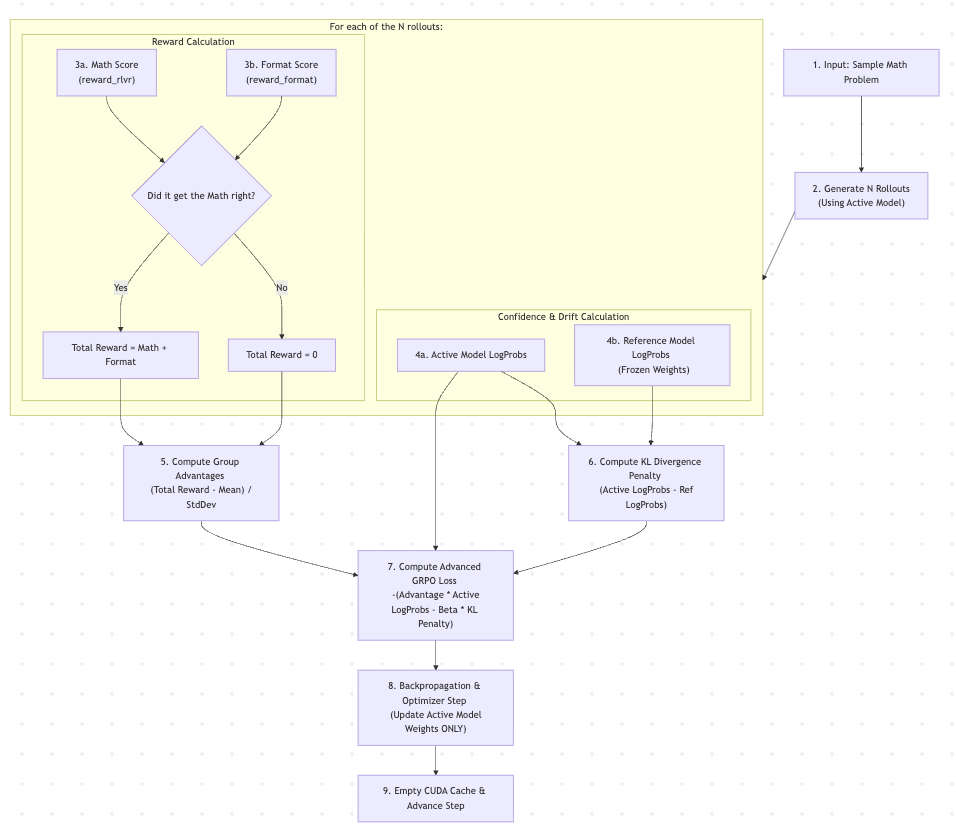

## What this script does
Upgrades Chapter 6's GRPO with two additions to make training more stable
and to shape *how* the model reasons, not just *whether* it gets the answer right.

---

## Key Concept: Chapter 6 vs Chapter 7 GRPO

| | Ch6 GRPO | Ch7 Advanced GRPO |
|---|---|---|
| **Reward signal** | Math correctness only (0 or 1) | Math + conditional format reward |
| **Drift control** | None | KL divergence penalty vs frozen reference |
| **Model copies** | 1 (active) | 2 (active + frozen reference) |
| **Risk addressed** | — | Reward hacking / training collapse |

---

## Addition 1: KL Divergence Penalty

### Why it exists
Without a constraint, RL training can "reward hack" — the model finds degenerate
outputs that score well (e.g. always writing `\boxed{42}`) but are incoherent.
The KL penalty keeps the active model anchored to the base distribution.

### How it works
A **frozen copy** of the base model (`ref_model`) is created once at training
start via `copy.deepcopy()` and never updated (`requires_grad=False`).

At each step, `sequence_logprob` is called **twice** — once for the active model,
once for the reference:

```
KL penalty ≈ log_prob(active) - log_prob(reference)
```

- Large positive KL → active model has drifted far from reference → penalised
- Near-zero KL → model barely changing → may indicate under-training

### In the loss formula
```
loss = -mean( advantage × log_prob(active) - beta × KL_penalty )
```
`beta=0.04` controls penalty strength. Higher beta = stays closer to reference.

---

## Addition 2: Conditional Format Reward (`reward_format`)

Rewards the model for wrapping its reasoning in `<think>...</think>` tags —
encouraging a structured reasoning scratchpad before the final answer
(same behaviour as DeepSeek-R1).

**Conditional gate — critical detail:**
```
if math_score == 0.0:
    format_score = 0.0   ← zeroed out even if tags are present

total_reward = math_score + (0.5 × format_score)
```
Format points are **only granted when the math is also correct**.
This prevents the model from learning to write well-formatted wrong answers.

---

## 3. Evaluation (`evaluate_ch7_model`)
Tracks **two metrics** independently after training:

| Metric | What it checks |
|---|---|
| **Math accuracy** | Extracted answer == ground truth (via hybrid parser) |
| **Format compliance** | `<think>` and `</think>` both present and correctly ordered |

Format compliance rate should be higher than a Ch6 baseline — if it isn't,
the format reward had no effect.

---

## 4. Training Loop (`run_ch7_advanced_training`)

```
Setup: active model (trainable) + ref_model (deepcopy, frozen)

For each step:
  1. ROLLOUT  — sample_response() × NUM_ROLLOUTS
  2. SCORE    — reward_rlvr + conditional reward_format → total_reward
  3. ADVANTAGE — group-relative normalisation (same as Ch6)
  4. LOSS     — advantage × log_prob(active) - beta × KL_penalty
  5. BACKWARD — loss.backward() + clip_grad_norm + optimizer.step()
  LOG: loss | avg_reward | KL drift (watch for collapse or stagnation)
```

**Key hyperparameters:**

| Parameter | Value | Why |
|---|---|---|
| `BETA` | 0.04 | KL penalty strength — anchors model to reference |
| `NUM_ROLLOUTS` | 2 | Fewer than Ch6; KL penalty compensates for stability |
| `format_weight` | 0.5 | Format reward worth half a correct math answer |

In [7]:
import torch
import copy
import requests
from pathlib import Path

# ── Chapter 2 utilities: hardware detection
from reasoning_from_scratch.ch02 import get_device

# ── Qwen3 model components (KVCache for fast generation)
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Model,
    Qwen3Tokenizer,
    QWEN_CONFIG_06_B,
    KVCache
)

# ── Chapter 3 utilities: prompt formatter, answer extractor, eval dataset
from reasoning_from_scratch.ch03 import (
    render_prompt,
    extract_final_candidate,
    load_math500_test
)

# ── Heavy LaTeX normaliser for grading
from reasoning_from_scratch.bonus.parser import normalize_text_hybrid

# ── Chapter 4 nucleus filter (reused inside the trajectory sampler)
from reasoning_from_scratch.ch04 import top_p_filter


# ─────────────────────────────────────────────
# 1. DATA & REWARD FUNCTIONS
# ─────────────────────────────────────────────

def load_math_train():
    """
    Downloads the training split of MATH (full dataset minus MATH-500),
    ensuring zero overlap with the held-out evaluation set.
    """
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "math_full_minus_math500/refs/heads/main/math_full_minus_math500.json"
    )
    return requests.get(url, timeout=30).json()


def reward_rlvr(answer_text, ground_truth):
    """
    Binary math correctness reward — unchanged from Chapter 6.

    Returns 1.0 if the extracted answer matches ground truth after LaTeX
    normalisation, 0.0 otherwise (including if no answer was found).
    """
    extracted = extract_final_candidate(answer_text, fallback=None)
    if not extracted:
        return 0.0
    return 1.0 if normalize_text_hybrid(extracted) == normalize_text_hybrid(ground_truth) else 0.0


def reward_format(answer_text):
    """
    NEW in Chapter 7 — Format reward: did the model use <think> tags correctly?

    Checks for the presence of BOTH <think> and </think> tags, AND that the
    opening tag appears before the closing tag (guards against reversed or
    malformed tags).

    Returns 1.0 if the format is correct, 0.0 otherwise.

    Why <think> tags? They encourage the model to externalise its reasoning
    in a structured scratchpad before committing to a final answer — the same
    behaviour seen in chain-of-thought reasoning models like DeepSeek-R1.

    Important: this reward is only granted when reward_rlvr also returns 1.0
    (see compute_grpo_loss_advanced). We never reward good formatting on a
    wrong answer — that would incentivise pretty-looking incorrect responses.
    """
    if "<think>" in answer_text and "</think>" in answer_text:
        think_start = answer_text.find("<think>")
        think_end   = answer_text.find("</think>")
        if think_start < think_end:
            return 1.0
    return 0.0


# ─────────────────────────────────────────────
# 2. SEQUENCE LOG-PROBABILITY
# ─────────────────────────────────────────────

def sequence_logprob(model, token_ids, prompt_len):
    """
    Computes the sum of log-probabilities of the answer tokens for a given
    model. Called twice per rollout — once for the active model, once for
    the frozen reference model — to compute the KL divergence penalty.

    Identical to the Chapter 6 implementation. See Chapter 6 notes for the
    full step-by-step breakdown of the causal offset and .gather() indexing.
    """
    logits   = model(token_ids.unsqueeze(0)).squeeze(0).float()  # (seq_len, vocab_size)
    selected = (
        torch.log_softmax(logits, dim=-1)[:-1]          # Causal shift: logits[i] → token[i+1]
        .gather(1, token_ids[1:].unsqueeze(-1))          # Pick log-prob of the actual next token
        .squeeze(-1)
    )
    return torch.sum(selected[prompt_len - 1:])          # Sum over answer tokens only


# ─────────────────────────────────────────────
# 3. TRAJECTORY SAMPLER
# ─────────────────────────────────────────────

@torch.no_grad()
def sample_response(
    model, tokenizer, prompt, device,
    max_new_tokens=256, temperature=0.8, top_p=0.9
):
    """
    Generates one stochastic trajectory using temperature + top-p sampling.
    Identical to the Chapter 6 implementation.

    temperature > 0 → stochastic sampling (used for training rollouts)
    temperature = 0 → greedy argmax (used for deterministic evaluation)

    Returns:
        full_token_ids : prompt + generated tokens (for sequence_logprob)
        prompt_len     : where the prompt ends in full_token_ids
        decoded_text   : the generated answer string (for reward functions)
    """
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    logits = model(input_ids.unsqueeze(0), cache=cache)[:, -1]

    generated = []

    for _ in range(max_new_tokens):
        if temperature > 0.0:
            probas     = top_p_filter(torch.softmax(logits / temperature, dim=-1), top_p)
            next_token = torch.multinomial(probas, num_samples=1)
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)

        if tokenizer.eos_token_id is not None and next_token.item() == tokenizer.eos_token_id:
            break

        generated.append(next_token.item())
        logits = model(next_token, cache=cache)[:, -1]

    full_token_ids = torch.cat([
        input_ids,
        torch.tensor(generated, device=device, dtype=input_ids.dtype)
    ])
    return full_token_ids, input_ids.numel(), tokenizer.decode(generated)


# ─────────────────────────────────────────────
# 4. ADVANCED GRPO LOSS (Chapter 7 Core)
# ─────────────────────────────────────────────

def compute_grpo_loss_advanced(
    model, ref_model, tokenizer, example, device,
    num_rollouts=2, beta=0.04, format_weight=0.5
):
    """
    Chapter 7 upgrade to the Chapter 6 GRPO loss. Two additions:

    ── Addition 1: KL Divergence Penalty ─────────────────────────────────
    A frozen copy of the model (ref_model) is loaded once at training start
    and never updated. At each step, we measure how far the active model has
    drifted from the reference by comparing their log-probs on the same
    trajectory:

        KL penalty ≈ log_prob(active) - log_prob(reference)

    This is added to the loss scaled by `beta`. A large positive KL means
    the active model assigns much higher probability to these tokens than
    the reference did — i.e. it has drifted significantly.

    Why penalise drift? Without this, RL training can collapse into
    "reward hacking" — the model finds degenerate outputs that score well
    on the reward function but are incoherent (e.g. repeating \boxed{42}
    forever). The KL penalty keeps the model anchored to the base
    distribution.

    ── Addition 2: Conditional Format Reward ─────────────────────────────
    A second reward signal is added for using <think> tags correctly.
    It is CONDITIONAL: format points are only granted if the math answer
    is also correct. This prevents the model from learning to write
    well-formatted wrong answers.

        total_reward = math_score + (format_weight × format_score)
        where format_score = 0 if math_score = 0

    ── Full loss formula ─────────────────────────────────────────────────
        loss = -mean( advantage × log_prob(active) - beta × KL_penalty )

    Args:
        beta         : KL penalty strength. Higher → stays closer to reference.
        format_weight: How much weight to give the format reward (default 0.5).

    Returns:
        pg_loss      : Scalar loss tensor — backpropagate this.
        roll_rewards : List of total rewards per rollout — for logging.
        kl_mean      : Mean KL divergence across rollouts — for monitoring drift.
    """
    roll_logps, ref_logps, roll_rewards = [], [], []
    prompt = render_prompt(example["problem"])

    # Sample in eval mode (no dropout) then restore training mode
    was_training = model.training
    model.eval()

    for _ in range(num_rollouts):
        token_ids, prompt_len, text = sample_response(model, tokenizer, prompt, device)

        # Active model log-prob (will flow through the gradient)
        roll_logps.append(sequence_logprob(model, token_ids, prompt_len))

        # Reference model log-prob (frozen — no gradient needed)
        with torch.no_grad():
            ref_logps.append(sequence_logprob(ref_model, token_ids, prompt_len))

        # Compute combined reward
        math_score   = reward_rlvr(text, example["answer"])
        format_score = reward_format(text)

        # Conditional gate: zero out format reward if math is wrong
        if math_score == 0.0:
            format_score = 0.0

        total_reward = math_score + (format_weight * format_score)
        roll_rewards.append(total_reward)

    if was_training:
        model.train()

    # ── Advantage normalisation (same as Chapter 6) ────────────────────────
    rewards    = torch.tensor(roll_rewards, device=device)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)

    active_logps_tensor = torch.stack(roll_logps)
    ref_logps_tensor    = torch.stack(ref_logps)

    # ── KL divergence approximation ────────────────────────────────────────
    # Positive KL → active model has drifted toward these tokens relative to ref
    # Negative KL → active model has moved away from these tokens
    kl_penalty = active_logps_tensor - ref_logps_tensor

    # ── Final loss ─────────────────────────────────────────────────────────
    # Both advantages and kl_penalty are detached — they are targets/penalties,
    # not part of the computational graph. Only active_logps flows gradients.
    pg_loss = -(advantages.detach() * active_logps_tensor - beta * kl_penalty.detach()).mean()

    return pg_loss, roll_rewards, kl_penalty.mean().item()


# ─────────────────────────────────────────────
# 5. DETERMINISTIC GENERATION (FOR EVALUATION)
# ─────────────────────────────────────────────

@torch.inference_mode()
def generate_greedy(model, tokenizer, prompt, device, max_new_tokens=512):
    """
    Greedy (argmax) generation — deterministic, no sampling.
    Used during evaluation so results are comparable across checkpoints.
    Identical to the Chapter 6 implementation.
    """
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device)
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    logits = model(input_ids.unsqueeze(0), cache=cache)[:, -1]
    generated = []

    for _ in range(max_new_tokens):
        next_token = torch.argmax(logits, dim=-1, keepdim=True)
        if tokenizer.eos_token_id is not None and next_token.item() == tokenizer.eos_token_id:
            break
        generated.append(next_token.item())
        logits = model(next_token, cache=cache)[:, -1]

    return tokenizer.decode(generated)


# ─────────────────────────────────────────────
# 6. EVALUATION ENGINE
# ─────────────────────────────────────────────

def evaluate_ch7_model(model, tokenizer, dataset_size=5):
    """
    Evaluates the trained model on two dimensions simultaneously:
      1. Mathematical accuracy — was the extracted answer correct?
      2. Format compliance   — did the model use <think> tags correctly?

    Both metrics are tracked independently so we can see whether the format
    reward actually changed model behaviour (format compliance rate should
    be higher than a Chapter 6 baseline that was never rewarded for it).

    Uses greedy decoding for determinism.
    """
    device = get_device()
    print(f"Using device: {device}")
    model.eval()

    math_eval_data = load_math500_test()
    if dataset_size is not None:
        math_eval_data = math_eval_data[:dataset_size]

    num_correct      = 0
    format_successes = 0

    print(f"\nStarting Chapter 7 Evaluation on {len(math_eval_data)} unseen questions...")
    print("Testing for both Mathematical Accuracy AND <think> tag Formatting...\n")

    for i, row in enumerate(math_eval_data, 1):
        prompt      = render_prompt(row["problem"])
        answer_text = generate_greedy(model, tokenizer, prompt, device)

        # Check format compliance — did the model externalise its reasoning?
        used_think_tags = "<think>" in answer_text and "</think>" in answer_text
        if used_think_tags:
            format_successes += 1

        # Extract and grade the math answer
        extracted  = extract_final_candidate(answer_text)
        pred       = normalize_text_hybrid(extracted)
        gold       = normalize_text_hybrid(row["answer"])
        is_correct = (pred == gold)
        num_correct += int(is_correct)

        print(f"--- Question {i} ---")
        print(f"Expected  : {row['answer']}")
        print(f"Extracted : {extracted!r}")
        print(f"Formatting: {'✅ Followed <think> Rules' if used_think_tags else '❌ Missed Formatting'}")
        print(f"Graded    : {'✅ CORRECT' if is_correct else '❌ INCORRECT'}\n")

    accuracy    = (num_correct      / len(math_eval_data)) * 100
    format_rate = (format_successes / len(math_eval_data)) * 100

    print("=========================================")
    print(f"Final Accuracy    : {num_correct}/{len(math_eval_data)} ({accuracy:.1f}%)")
    print(f"Format Compliance : {format_successes}/{len(math_eval_data)} ({format_rate:.1f}%)")
    print("=========================================")


# ─────────────────────────────────────────────
# 7. PRODUCTION TRAINING LOOP
# ─────────────────────────────────────────────

def run_ch7_advanced_training():
    """
    Full Chapter 7 GRPO training loop — two upgrades over Chapter 6:
      1. A frozen reference model is created at startup and passed into
         compute_grpo_loss_advanced at every step to compute the KL penalty.
      2. A format reward is added alongside the math reward, gated on
         correctness so it never reinforces well-formatted wrong answers.

    Everything else (AdamW, bfloat16, grad clipping, one example per step)
    is identical to Chapter 6.

    KL drift is logged alongside loss and reward so we can watch whether
    the model is drifting too far from the reference (high KL) or staying
    too conservative (near-zero KL with no improvement).
    """

    device = get_device()
    print(f"Using device: {device}")

    download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")
    tokenizer = Qwen3Tokenizer(tokenizer_file_path="qwen3/tokenizer-base.json")

    # ── Active model (weights will be updated) ────────────────────────────
    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.to(torch.bfloat16)
    model.load_state_dict(
        torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device, weights_only=True)
    )
    model.to(device)

    # ── Frozen reference model (deep copy — completely independent object) ─
    # deepcopy creates a separate model with the same initial weights.
    # requires_grad=False ensures its parameters never accumulate gradients
    # or get touched by the optimiser — it stays frozen for the full run.
    print("Loading Frozen Reference Model into memory...")
    ref_model = copy.deepcopy(model)
    ref_model.eval()
    for param in ref_model.parameters():
        param.requires_grad = False  # Freeze: no gradients, no updates

    # ── Data & hyperparameters ────────────────────────────────────────────
    math_train_data = load_math_train()

    STEPS        = 50    # Total gradient steps
    NUM_ROLLOUTS = 2     # Trajectories per step (fewer than Ch6 — KL penalty compensates)
    BETA         = 0.04  # KL penalty strength — higher pushes model to stay near reference

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
    model.train()

    print(f"\nStarting Advanced GRPO Training for {STEPS} steps...")

    for step in range(1, STEPS + 1):
        train_example = math_train_data[step]
        print(f"\n[Step {step}] Training on: {train_example['problem'][:50]}...")

        optimizer.zero_grad()

        # Pass BOTH models — active (trainable) + reference (frozen)
        loss, rewards, kl_div = compute_grpo_loss_advanced(
            model, ref_model, tokenizer, train_example, device,
            num_rollouts=NUM_ROLLOUTS,
            beta=BETA
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Prevent exploding gradients
        optimizer.step()
        torch.cuda.empty_cache()  # Free fragmented GPU memory

        avg_reward = sum(rewards) / len(rewards)
        # KL drift logged here: rising KL = model moving away from reference
        print(f"   📈 Loss: {loss.item():.4f} | Avg Reward: {avg_reward:.2f} | KL Drift: {kl_div:.4f}")

    print("\nAdvanced Training complete!")

    # ── Post-training evaluation ───────────────────────────────────────────
    # Wrapped in try/except in case this cell is accidentally run standalone
    # without the training cell having populated `model` and `tokenizer`.
    try:
        evaluate_ch7_model(model, tokenizer, dataset_size=50)
    except NameError:
        print("🚨 Error: 'model' or 'tokenizer' not found.")
        print(
            "You must run the Chapter 7 Advanced GRPO Training block first "
            "so the active model is in memory!"
        )


# ── Entry point ────────────────────────────────────────────────────────────────
run_ch7_advanced_training()

Using NVIDIA CUDA GPU
Using device: cuda
✓ qwen3/qwen3-0.6B-base.pth already up-to-date
Loading Frozen Reference Model into memory...

Starting Advanced GRPO Training for 50 steps...

[Step 1] Training on: A rectangular band formation is a formation with $...
   📈 Loss: -0.0000 | Avg Reward: 0.00 | KL Drift: 0.0000

[Step 2] Training on: What is the degree of the polynomial $(4 +5x^3 +10...
   📈 Loss: 6.0404 | Avg Reward: 0.50 | KL Drift: 0.0000

[Step 3] Training on: Evaluate $\left\lceil3\left(6-\frac12\right)\right...
   📈 Loss: 5.8918 | Avg Reward: 0.50 | KL Drift: 1.0688

[Step 4] Training on: Sam is hired for a 20-day period. On days that he ...
   📈 Loss: 0.2004 | Avg Reward: 0.00 | KL Drift: 5.0094

[Step 5] Training on: Find the center of the circle with equation $x^2 -...
   📈 Loss: 0.1038 | Avg Reward: 0.00 | KL Drift: 2.5949

[Step 6] Training on: What are all values of $p$ such that for every $q>...
   📈 Loss: 0.0775 | Avg Reward: 0.00 | KL Drift: 1.9380

[Step 7] Training